# Training - Fake News Detection (ISOT Dataset)

**Prerequisite:** Run `Training_LIAR&ISOT.ipynb` first to generate `artifacts/`.

This notebook loads the preprocessed artifacts and trains a classifier.
</br>Set `MODEL_TYPE` in the Hyperparameters cell to choose between: **RNN**, **GRU**, **LSTM**, or **Transformer**.
</br>Set `DATABASE` in the Hyperparameters cell to choose between: **ISOT**, **LIAR**, or **BOTH**.

## 1. Hyperparameters

In [5]:
# ── Model selection ──────────────────────────────────────────────
MODEL_TYPE = "RNN"  # Options: "RNN", "GRU", "LSTM"

# --- DataBase --------------
DATABASE= "ISOT" #Options: ISOT, LIAR, BOTH

# ── Shared hyperparameters ──────────────────────────────────────
EMBEDDING_DIM = 128
LEARNING_RATE = 1e-3 #0.01
BATCH_SIZE = 32
NUM_EPOCHS = 10
PAD_ID = 0

# ── Early stopping ──────────────────────────────────────────────
EARLY_STOPPING_PATIENCE = 3  # stop after N epochs with no val loss improvement
EARLY_STOPPING_ACC_THRESHOLD = 1.0  # stop immediately if val accuracy reaches this

# ── RNN / GRU / LSTM hyperparameters ───────────────────────────
HIDDEN_SIZE = 64
BIDIRECTIONAL = True

## 2. Setup & Verify Artifacts

In [2]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from datetime import datetime

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/aidl-final-project"
ARTIFACTS_DIR = os.path.join(f"{DRIVE_PROJECT_DIR}/artifacts", DATABASE)

assert os.path.exists(os.path.join(ARTIFACTS_DIR, "train_ids.pt")), \
    "Run Training_LIAR&ISOT.ipynb first!"
print("Artifacts found.")

Mounted at /content/drive
Artifacts found.


## 3. Load Preprocessing Artifacts

In [3]:
# Load tensors and vocabulary based on DATABASE selection
X_train = torch.load(os.path.join(ARTIFACTS_DIR, "train_ids.pt"))
y_train = torch.load(os.path.join(ARTIFACTS_DIR, "train_labels.pt"))
X_val = torch.load(os.path.join(ARTIFACTS_DIR, "val_ids.pt"))
y_val = torch.load(os.path.join(ARTIFACTS_DIR, "val_labels.pt"))
X_test = torch.load(os.path.join(ARTIFACTS_DIR, "test_ids.pt"))
y_test = torch.load(os.path.join(ARTIFACTS_DIR, "test_labels.pt"))


with open(os.path.join(ARTIFACTS_DIR, "stoi.json")) as f:
    stoi = json.load(f)
# Load summary
with open(os.path.join(ARTIFACTS_DIR, "summary.json")) as f:
    summary = json.load(f)

vocab_size = summary["vocab_size"]
max_length = summary["max_length"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Vocab size: {vocab_size}, Max length: {max_length}")

X_train: torch.Size([24124, 512]), y_train: torch.Size([24124])
X_val:   torch.Size([6031, 512]),   y_val:   torch.Size([6031])
X_test:  torch.Size([3351, 512]),  y_test:  torch.Size([3351])
Vocab size: 44721, Max length: 512


## 4. Create DataLoaders

In [4]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader: {len(train_dataloader)} batches of size {BATCH_SIZE}")
print(f"Val DataLoader:   {len(val_dataloader)} batches of size {BATCH_SIZE}")
print(f"Test DataLoader:  {len(test_dataloader)} batches of size {BATCH_SIZE}")

Train DataLoader: 754 batches of size 32
Val DataLoader:   189 batches of size 32
Test DataLoader:  105 batches of size 32


## 5. Model Definitions

### 5.1 GRU

In [7]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, bidirectional, num_classes=1):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, ## 45k
            embedding_dim=embedding_dim, ## 128
            padding_idx=PAD_ID ## 0
        )

        self.gru = nn.GRU(
            input_size=embedding_dim, ## 128
            hidden_size=hidden_size, ## 64
            batch_first=True,
            bidirectional=bidirectional
        )

        classifier_input_size = 2 * hidden_size if bidirectional else hidden_size
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        embedded = self.embedding.forward(x)
        output, h_n = self.gru.forward(embedded)
        if self.gru.bidirectional:
            final_hidden = torch.cat((h_n[0], h_n[1]), dim=1)
        else:
            final_hidden = h_n.squeeze(0)

        logits = self.classifier(final_hidden)
        return logits

### 5.2 RNN

In [8]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, bidirectional, num_classes=1):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=PAD_ID
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=bidirectional
        )

        classifier_input_size = 2 * hidden_size if bidirectional else hidden_size
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, h_n = self.rnn(embedded)

        if self.rnn.bidirectional:
            final_hidden = torch.cat((h_n[0], h_n[1]), dim=1)
        else:
            final_hidden = h_n.squeeze(0)

        logits = self.classifier(final_hidden)
        return logits

### 5.3 LSTM

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, bidirectional, num_classes=1,
                 num_layers=1, dropout=0.0, ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_size,
                            num_layers,
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=bidirectional)

        classifier_input_size = 2 * hidden_size if bidirectional else hidden_size
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        embedded = self.embedding.forward(x)
        output, (h_n, c_n) = self.lstm.forward(embedded)

        if self.lstm.bidirectional:
            final_hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        else:
            final_hidden = h_n[-1, :, :]

        logits = self.classifier(final_hidden)
        return logits

## 6. Model Instantiation

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MODELS = {
    "GRU": lambda: GRUClassifier(
        vocab_size=vocab_size, embedding_dim=EMBEDDING_DIM,
        hidden_size=HIDDEN_SIZE, bidirectional=BIDIRECTIONAL, num_classes=1,
    ),
    "RNN": lambda: RNNClassifier(
        vocab_size=vocab_size, embedding_dim=EMBEDDING_DIM,
        hidden_size=HIDDEN_SIZE, bidirectional=BIDIRECTIONAL, num_classes=1,
    ),
    "LSTM": lambda: LSTMClassifier(
        vocab_size=vocab_size, embedding_dim=EMBEDDING_DIM,
        hidden_size=HIDDEN_SIZE, bidirectional=BIDIRECTIONAL,
        num_classes=1, num_layers=1, dropout=0.0
    )
}

assert MODEL_TYPE in MODELS, f"Unknown MODEL_TYPE: {MODEL_TYPE}. Choose from {list(MODELS.keys())}"
model = MODELS[MODEL_TYPE]()
model.to(device)
print(f"Model: {MODEL_TYPE}")
print(model)

Using device: cuda
Model: RNN
RNNClassifier(
  (embedding): Embedding(44721, 128, padding_idx=0)
  (rnn): RNN(128, 64, batch_first=True, bidirectional=True)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)


## 7. Loss Function & Optimizer

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 8. Training & Evaluation Functions

In [12]:
def train_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).long()
        correct += (predicted == labels.long()).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate_epoch(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).long()
            correct += (predicted == labels.long()).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

## 9. Training Loop

In [13]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
epochs_without_improvement = 0

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_dataloader, criterion, optimizer)
    val_loss, val_acc = evaluate_epoch(model, val_dataloader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # Early stopping: accuracy threshold
    if val_acc >= EARLY_STOPPING_ACC_THRESHOLD:
        print(f"  ↳ Val accuracy {val_acc:.4f} >= {EARLY_STOPPING_ACC_THRESHOLD}. Stopping early.")
        best_model_state = model.state_dict().copy()
        best_val_loss = val_loss
        break

    # Early stopping: patience on val loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_state = model.state_dict().copy()
        print(f"  ↳ New best val loss. Saving checkpoint.")
    else:
        epochs_without_improvement += 1
        print(f"  ↳ No improvement for {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE} epochs.")
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}.")
            break

# Restore best model weights
model.load_state_dict(best_model_state)
print(f"\nTraining complete. Restored best model from epoch {val_losses.index(best_val_loss)+1} "
      f"(val_loss={best_val_loss:.4f}).")

Starting training...
Epoch 1/10: Train Loss=0.3083, Train Acc=0.8762 | Val Loss=0.1871, Val Acc=0.9385
  ↳ New best val loss. Saving checkpoint.
Epoch 2/10: Train Loss=0.1376, Train Acc=0.9556 | Val Loss=0.1449, Val Acc=0.9574
  ↳ New best val loss. Saving checkpoint.
Epoch 3/10: Train Loss=0.0792, Train Acc=0.9762 | Val Loss=0.1387, Val Acc=0.9612
  ↳ New best val loss. Saving checkpoint.
Epoch 4/10: Train Loss=0.0512, Train Acc=0.9847 | Val Loss=0.1317, Val Acc=0.9581
  ↳ New best val loss. Saving checkpoint.
Epoch 5/10: Train Loss=0.0296, Train Acc=0.9918 | Val Loss=0.1360, Val Acc=0.9597
  ↳ No improvement for 1/3 epochs.
Epoch 6/10: Train Loss=0.0218, Train Acc=0.9939 | Val Loss=0.1446, Val Acc=0.9665
  ↳ No improvement for 2/3 epochs.
Epoch 7/10: Train Loss=0.0157, Train Acc=0.9952 | Val Loss=0.1774, Val Acc=0.9629
  ↳ No improvement for 3/3 epochs.
Early stopping at epoch 7.

Training complete. Restored best model from epoch 4 (val_loss=0.1317).


In [14]:
current_time = datetime.now()
timehour = current_time.strftime("%Y%m%d_%H%M")

OUTPUT_DIR = os.path.join(DRIVE_PROJECT_DIR, f"outputs/{MODEL_TYPE.lower()}_{DATABASE}_{timehour}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 10. Test Set Evaluation

In [15]:
# Generate predictions on TEST set using the best model
# (val set was used for early stopping / model selection, so test is the true held-out evaluation)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predicted = (torch.sigmoid(outputs) > 0.5).long().squeeze(1)
        all_preds.append(predicted.cpu().numpy())
        all_labels.append(labels.numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)
print(f"Test predictions generated: {len(y_true)} samples")

Test predictions generated: 3351 samples


### 10.1 Classification Report (Test Set)

In [16]:
target_names = ["Fake (0)", "True (1)"]
print("Classification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=target_names))

report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

Classification Report (Test Set):
              precision    recall  f1-score   support

    Fake (0)       0.98      0.66      0.78      1253
    True (1)       0.83      0.99      0.90      2098

    accuracy                           0.87      3351
   macro avg       0.90      0.82      0.84      3351
weighted avg       0.88      0.87      0.86      3351



### 10.2 Confusion Matrix (Test Set)

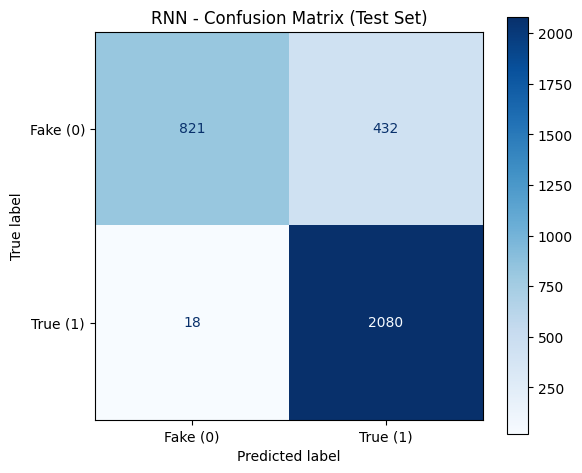

Saved confusion_matrix.png to /content/drive/MyDrive/aidl-final-project/outputs/rnn_ISOT_20260317_1021/


In [17]:
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax_cm, cmap='Blues', values_format='d')
ax_cm.set_title(f'{MODEL_TYPE} - Confusion Matrix (Test Set)')
fig_cm.tight_layout()
fig_cm.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved confusion_matrix.png to {OUTPUT_DIR}/")

## 11. Visualize Training Results

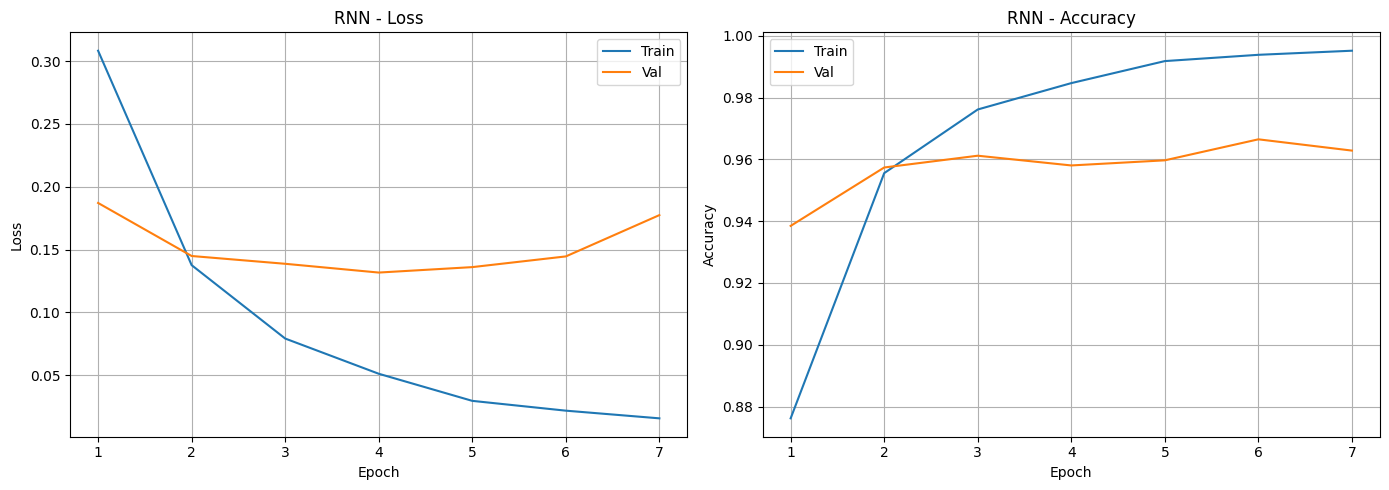

Saved training_curves.png to /content/drive/MyDrive/aidl-final-project/outputs/rnn_ISOT_20260317_1021/


In [18]:
epochs = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train')
ax1.plot(epochs, val_losses, label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title(f'{MODEL_TYPE} - Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_accuracies, label='Train')
ax2.plot(epochs, val_accuracies, label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title(f'{MODEL_TYPE} - Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved training_curves.png to {OUTPUT_DIR}/")

## 12. Save Model & Results

In [ ]:
# Save model weights
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "model.pt"))

# Save training history
history = {
    "train_loss": train_losses,
    "train_acc": train_accuracies,
    "val_loss": val_losses,
    "val_acc": val_accuracies,
}
with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)

# Save final metrics (including per-class precision/recall/F1 on test set)
test_acc = report_dict["accuracy"]
metrics = {
    "model_type": MODEL_TYPE,
    "final_train_loss": train_losses[-1],
    "final_train_acc": train_accuracies[-1],
    "final_val_loss": val_losses[-1],
    "final_val_acc": val_accuracies[-1],
    "best_val_acc": max(val_accuracies),
    "best_val_epoch": val_accuracies.index(max(val_accuracies)) + 1,
    "epochs_trained": len(train_losses),
    "test_acc": test_acc,
    "test_precision_fake": report_dict["Fake (0)"]["precision"],
    "test_recall_fake": report_dict["Fake (0)"]["recall"],
    "test_f1_fake": report_dict["Fake (0)"]["f1-score"],
    "test_precision_true": report_dict["True (1)"]["precision"],
    "test_recall_true": report_dict["True (1)"]["recall"],
    "test_f1_true": report_dict["True (1)"]["f1-score"],
    "test_macro_f1": report_dict["macro avg"]["f1-score"],
    "test_weighted_f1": report_dict["weighted avg"]["f1-score"],
}
with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Model and results saved to {OUTPUT_DIR}/")
print(json.dumps(metrics, indent=2))

## 13. Summary

In [19]:
# Display experiment summary: preprocessing config + model hyperparameters + key results
print("=" * 70)
print(f"EXPERIMENT SUMMARY: {MODEL_TYPE}")
print("=" * 70)

print("\n--- Preprocessing Config ---")
print(f"  Vocab size:     {summary['vocab_size']:,}")
print(f"  Max length:     {summary['max_length']}")
print(f"  Train samples:  {summary['train_samples']:,}")
print(f"  Val samples:    {summary['val_samples']:,}")
print(f"  Test samples:   {summary['test_samples']:,}")

print("\n--- Model Hyperparameters ---")
print(f"  Model type:     {MODEL_TYPE}")
print(f"  Embedding dim:  {EMBEDDING_DIM}")
if MODEL_TYPE in ("RNN", "GRU", "LSTM"):
    print(f"  Hidden size:    {HIDDEN_SIZE}")
    print(f"  Bidirectional:  {BIDIRECTIONAL}")
print(f"  Learning rate:  {LEARNING_RATE}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Max epochs:     {NUM_EPOCHS}")
print(f"  Early stop patience:       {EARLY_STOPPING_PATIENCE}")
print(f"  Early stop acc threshold:  {EARLY_STOPPING_ACC_THRESHOLD}")

print("\n--- Training Results ---")
print(f"  Epochs trained: {len(train_losses)}")
print(f"  Best val acc:   {max(val_accuracies):.4f} (epoch {val_accuracies.index(max(val_accuracies))+1})")
print(f"  Final val loss: {val_losses[-1]:.4f}")

print("\n--- Test Results (held-out) ---")
print(f"  Test accuracy:  {report_dict['accuracy']:.4f}")
print(f"  Macro F1:       {report_dict['macro avg']['f1-score']:.4f}")
print(f"  Weighted F1:    {report_dict['weighted avg']['f1-score']:.4f}")
print("=" * 70)

EXPERIMENT SUMMARY: RNN

--- Preprocessing Config ---
  Vocab size:     44,721
  Max length:     512
  Train samples:  24,124
  Val samples:    6,031
  Test samples:   3,351

--- Model Hyperparameters ---
  Model type:     RNN
  Embedding dim:  128
  Hidden size:    64
  Bidirectional:  True
  Learning rate:  0.001
  Batch size:     32
  Max epochs:     10
  Early stop patience:       3
  Early stop acc threshold:  1.0

--- Training Results ---
  Epochs trained: 7
  Best val acc:   0.9665 (epoch 6)
  Final val loss: 0.1774

--- Test Results (held-out) ---
  Test accuracy:  0.8657
  Macro F1:       0.8436
  Weighted F1:    0.8585


## 14. Generate Markdown Report

In [20]:
# Generate experiment_report.md for the GitHub README
model_type_lower = MODEL_TYPE.lower()

# Build hyperparameters section based on model type
hp_rows = f"""| Embedding dim | {EMBEDDING_DIM} |
| Hidden size | {HIDDEN_SIZE} |
| Bidirectional | {BIDIRECTIONAL} |"""

report = f"""### Experiment: {MODEL_TYPE}

#### Hypothesis

<!-- TODO: What do you expect to learn/observe from this experiment? -->

#### Experiment Setup

**Preprocessing:**

| Parameter | Value |
|-----------|-------|
| Vocab size | {summary['vocab_size']:,} |
| Max length | {summary['max_length']} |
| Train samples | {summary['train_samples']:,} |
| Val samples | {summary['val_samples']:,} |
| Test samples | {summary['test_samples']:,} |
| Cleaning | lowercase + stopword removal + lemmatization |
| Tokenizer | regex alphabetic `[a-z]+(?:'[a-z]+)?` |

**Model architecture:** {MODEL_TYPE} ({'bidirectional' if MODEL_TYPE in ('RNN','GRU','LSTM') and BIDIRECTIONAL else 'unidirectional' if MODEL_TYPE in ('RNN','GRU','LSTM') else 'encoder-only'})

| Hyperparameter | Value |
|----------------|-------|
{hp_rows}
| Learning rate | {LEARNING_RATE} |
| Batch size | {BATCH_SIZE} |
| Max epochs | {NUM_EPOCHS} |
| Early stopping patience | {EARLY_STOPPING_PATIENCE} |
| Early stopping acc threshold | {EARLY_STOPPING_ACC_THRESHOLD} |

#### Results

Trained for {len(train_losses)} epochs (best val acc: {max(val_accuracies):.4f} at epoch {val_accuracies.index(max(val_accuracies))+1}).

**Test set evaluation** ({summary['test_samples']:,} samples):

| Metric | Fake (0) | True (1) | Macro Avg |
|--------|----------|----------|-----------|
| Precision | {report_dict['Fake (0)']['precision']:.4f} | {report_dict['True (1)']['precision']:.4f} | {report_dict['macro avg']['precision']:.4f} |
| Recall | {report_dict['Fake (0)']['recall']:.4f} | {report_dict['True (1)']['recall']:.4f} | {report_dict['macro avg']['recall']:.4f} |
| F1-score | {report_dict['Fake (0)']['f1-score']:.4f} | {report_dict['True (1)']['f1-score']:.4f} | {report_dict['macro avg']['f1-score']:.4f} |

**Test accuracy:** {report_dict['accuracy']:.4f} | **Weighted F1:** {report_dict['weighted avg']['f1-score']:.4f}

**Training curves:**

![Training curves](outputs/{model_type_lower}/training_curves.png)

**Confusion matrix (test set):**

![Confusion matrix](outputs/{model_type_lower}/confusion_matrix.png)

#### Conclusions

<!-- TODO: What insights do you get from the results? Do they lead to a new hypothesis? -->

---
"""

report_path = os.path.join(OUTPUT_DIR, "experiment_report.md")
with open(report_path, "w") as f:
    f.write(report)

print(f"Saved experiment_report.md to {OUTPUT_DIR}/")
print("\n--- Preview ---\n")
print(report)

Saved experiment_report.md to /content/drive/MyDrive/aidl-final-project/outputs/rnn_ISOT_20260317_1021/

--- Preview ---

### Experiment: RNN

#### Hypothesis

<!-- TODO: What do you expect to learn/observe from this experiment? -->

#### Experiment Setup

**Preprocessing:**

| Parameter | Value |
|-----------|-------|
| Vocab size | 44,721 |
| Max length | 512 |
| Train samples | 24,124 |
| Val samples | 6,031 |
| Test samples | 3,351 |
| Cleaning | lowercase + stopword removal + lemmatization |
| Tokenizer | regex alphabetic `[a-z]+(?:'[a-z]+)?` |

**Model architecture:** RNN (bidirectional)

| Hyperparameter | Value |
|----------------|-------|
| Embedding dim | 128 |
| Hidden size | 64 |
| Bidirectional | True |
| Learning rate | 0.001 |
| Batch size | 32 |
| Max epochs | 10 |
| Early stopping patience | 3 |
| Early stopping acc threshold | 1.0 |

#### Results

Trained for 7 epochs (best val acc: 0.9665 at epoch 6).

**Test set evaluation** (3,351 samples):

| Metric | Fake (0) | T